In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from os.path import exists

sys.path.append('../..')

In [3]:
import pylab as plt
import pandas as pd
import numpy as np
from loguru import logger
import seaborn as sns

from stable_baselines3 import PPO, DQN

In [4]:
from vimms.Common import POSITIVE, set_log_level_warning, load_obj, save_obj
from vimms.ChemicalSamplers import UniformRTAndIntensitySampler, GaussianChromatogramSampler, UniformMZFormulaSampler, \
    MZMLFormulaSampler, MZMLRTandIntensitySampler, MZMLChromatogramSampler
from vimms.Noise import UniformSpikeNoise
from vimms.Evaluation import evaluate_real
from vimms.Chemicals import ChemicalMixtureFromMZML
from vimms.Roi import RoiBuilderParams, SmartRoiParams

from mass_spec_utils.data_import.mzmine import load_picked_boxes

from vimms_gym.env import DDAEnv
from vimms_gym.chemicals import generate_chemicals
from vimms_gym.evaluation import evaluate, run_method

/opt/anaconda3/envs/vimms-gym/lib/python3.9/site-packages/statsmodels/compat/pandas.py:61: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import Int64Index as NumericIndex
/opt/anaconda3/envs/vimms-gym/lib/python3.9/site-packages/psims/mzmlb/writer.py:15: UserWarning: hdf5plugin is missing! Only the slower GZIP compression scheme will be available! Please install hdf5plugin to be able to use Blosc.
  warnings.warn(


# 1. Parameters

In [5]:
# n_chemicals = (200, 500)
# mz_range = (100, 600)
# rt_range = (0, 300)
# intensity_range = (1E5, 1E10)

In [6]:
n_chemicals = (2000, 5000)
mz_range = (100, 600)
rt_range = (200, 1000)
intensity_range = (1E4, 1E10)

In [7]:
min_mz = mz_range[0]
max_mz = mz_range[1]
min_rt = rt_range[0]
max_rt = rt_range[1]
min_log_intensity = np.log(intensity_range[0])
max_log_intensity = np.log(intensity_range[1])

In [8]:
isolation_window = 0.7
N = 10
rt_tol = 15
mz_tol = 10
min_ms1_intensity = 5000
ionisation_mode = POSITIVE

enable_spike_noise = True
noise_density = 0.1
noise_max_val = 1E3

In [9]:
mz_sampler = UniformMZFormulaSampler(min_mz=min_mz, max_mz=max_mz)
ri_sampler = UniformRTAndIntensitySampler(min_rt=min_rt, max_rt=max_rt,
                                          min_log_intensity=min_log_intensity,
                                          max_log_intensity=max_log_intensity)
cr_sampler = GaussianChromatogramSampler()
samplers = {
    'mz': mz_sampler,
    'rt_intensity': ri_sampler,
    'chromatogram': cr_sampler
}

In [10]:
params = {
    'chemical_creator': {
        'mz_range': mz_range,
        'rt_range': rt_range,
        'intensity_range': intensity_range,
        'n_chemicals': n_chemicals,
        'mz_sampler': mz_sampler,
        'ri_sampler': ri_sampler,
        'cr_sampler': cr_sampler,
    },
    'noise': {
        'enable_spike_noise': enable_spike_noise,
        'noise_density': noise_density,
        'noise_max_val': noise_max_val,
        'mz_range': mz_range
    },
    'env': {
        'ionisation_mode': ionisation_mode,
        'rt_range': rt_range,
        'isolation_window': isolation_window,
        'mz_tol': mz_tol,
        'rt_tol': rt_tol,
    }
}

In [11]:
max_peaks = 100
in_dir = 'results_%d_%d' % (max_peaks, rt_tol)

In [12]:
n_eval_episodes = 10
deterministic = True

# 2. Evaluation

#### Generate some chemical sets

In [13]:
set_log_level_warning()

1

In [14]:
eval_dir = 'evaluation'
methods = [
    'PPO',
    'TopN',
    'random',
]

In [15]:
chemical_creator_params = params['chemical_creator']

chem_list = []
for i in range(n_eval_episodes):
    print(i)
    chems = generate_chemicals(chemical_creator_params)
    chem_list.append(chems)

0
1
2
3
4
5
6
7
8
9


#### Run different methods

In [16]:
for chems in chem_list:
    print(len(chems))

4747
3597
3451
4381
2250
3790
4856
3967
4512
2824


In [17]:
max_peaks

100

In [18]:
out_dir = '%s/eval_%d_%d' % (eval_dir, max_peaks, rt_tol)
in_dir, out_dir

('results_100_15', 'evaluation/eval_100_15')

#### Compare to Top-10

In [19]:
copy_params = dict(params)
copy_params['env']['rt_tol'] = rt_tol

method_eval_results = {}
for method in methods:
    banner = 'method = %s max_peaks = %d rt_tol = %d' % (method, max_peaks, rt_tol)
    print(banner)
    print()

    if method == 'PPO':
        fname = os.path.join(in_dir, 'model_%s.zip' % method)
        model = PPO.load(fname)
    elif method == 'DQN':
        fname = os.path.join(in_dir, 'model_%s.zip' % method)
        model = DQN.load(fname)
    else:
        model = None

    env = DDAEnv(max_peaks, copy_params)
    eval_results = run_method(env, chem_list, method, out_dir, min_ms1_intensity=min_ms1_intensity, model=model,
                              N=10, print_eval=True)
    method_eval_results[method] = eval_results
    print()

method = PPO max_peaks = 100 rt_tol = 15

Episode 0 finished after 3539 timesteps with reward 759.5319793135614
{'coverage_prop': '0.446', 'intensity_prop': '0.280', 'ms1/ms2 ratio': '0.150', 'efficiency': '0.687'}
Episode 1 finished after 3492 timesteps with reward 717.381906257843
{'coverage_prop': '0.527', 'intensity_prop': '0.334', 'ms1/ms2 ratio': '0.170', 'efficiency': '0.635'}
Episode 2 finished after 3489 timesteps with reward 689.8589295801163
{'coverage_prop': '0.521', 'intensity_prop': '0.334', 'ms1/ms2 ratio': '0.172', 'efficiency': '0.604'}
Episode 3 finished after 3525 timesteps with reward 750.1097108132906
{'coverage_prop': '0.464', 'intensity_prop': '0.295', 'ms1/ms2 ratio': '0.156', 'efficiency': '0.666'}
Episode 4 finished after 3410 timesteps with reward 616.1833004985003
{'coverage_prop': '0.675', 'intensity_prop': '0.441', 'ms1/ms2 ratio': '0.210', 'efficiency': '0.539'}
Episode 5 finished after 3491 timesteps with reward 730.0130666608292
{'coverage_prop': '0.504

#### Test classic controllers in ViMMS

In [20]:
from vimms.MassSpec import IndependentMassSpectrometer
from vimms.Controller import TopNController, TopN_SmartRoiController, WeightedDEWController
from vimms.Environment import Environment

Run Top-N Controller

In [21]:
method = 'TopN_Controller'
print('method = %s' % method)
print()

eval_results = []
for i in range(len(chem_list)):
    
    spike_noise = None
    if enable_spike_noise:
        noise_params = params['noise']
        noise_density = noise_params['noise_density']
        noise_max_val = noise_params['noise_max_val']
        noise_min_mz = noise_params['mz_range'][0]
        noise_max_mz = noise_params['mz_range'][1]
        spike_noise = UniformSpikeNoise(noise_density, noise_max_val, min_mz=noise_min_mz,
                                        max_mz=noise_max_mz)

    chems = chem_list[i]
    mass_spec = IndependentMassSpectrometer(ionisation_mode, chems, spike_noise=spike_noise)
    controller = TopNController(ionisation_mode, N, isolation_window, mz_tol, rt_tol,
                                min_ms1_intensity)
    env = Environment(mass_spec, controller, min_rt, max_rt, progress_bar=False, out_dir=out_dir,
                      out_file='%s_%d.mzML' % (method, i))
    env.run()
    
    eval_res = evaluate(env)
    eval_results.append(eval_res)
    print('Episode %d finished' % i)
    print(eval_res)
    
method_eval_results[method] = eval_results

method = TopN_Controller

Episode 0 finished
{'coverage_prop': '0.401', 'intensity_prop': '0.322', 'ms1/ms2 ratio': '0.101', 'efficiency': '0.572'}
Episode 1 finished
{'coverage_prop': '0.466', 'intensity_prop': '0.377', 'ms1/ms2 ratio': '0.102', 'efficiency': '0.504'}
Episode 2 finished
{'coverage_prop': '0.470', 'intensity_prop': '0.381', 'ms1/ms2 ratio': '0.103', 'efficiency': '0.489'}
Episode 3 finished
{'coverage_prop': '0.412', 'intensity_prop': '0.331', 'ms1/ms2 ratio': '0.102', 'efficiency': '0.544'}
Episode 4 finished
{'coverage_prop': '0.600', 'intensity_prop': '0.488', 'ms1/ms2 ratio': '0.108', 'efficiency': '0.410'}
Episode 5 finished
{'coverage_prop': '0.449', 'intensity_prop': '0.356', 'ms1/ms2 ratio': '0.102', 'efficiency': '0.512'}
Episode 6 finished
{'coverage_prop': '0.405', 'intensity_prop': '0.322', 'ms1/ms2 ratio': '0.101', 'efficiency': '0.591'}
Episode 7 finished
{'coverage_prop': '0.435', 'intensity_prop': '0.349', 'ms1/ms2 ratio': '0.101', 'efficiency': '0.519'

Run SmartROI Controller

In [22]:
method = 'SmartROI_Controller'
print('method = %s' % method)
print()

eval_results = []
for i in range(len(chem_list)):
    
    spike_noise = None
    if enable_spike_noise:
        noise_params = params['noise']
        noise_density = noise_params['noise_density']
        noise_max_val = noise_params['noise_max_val']
        noise_min_mz = noise_params['mz_range'][0]
        noise_max_mz = noise_params['mz_range'][1]
        spike_noise = UniformSpikeNoise(noise_density, noise_max_val, min_mz=noise_min_mz,
                                        max_mz=noise_max_mz)

    chems = chem_list[i]
    mass_spec = IndependentMassSpectrometer(ionisation_mode, chems, spike_noise=spike_noise)
    
    roi_params = RoiBuilderParams(min_roi_intensity=500, min_roi_length=0)    
    smartroi_params = SmartRoiParams()
    controller = TopN_SmartRoiController(ionisation_mode, isolation_window, N, mz_tol, rt_tol,
                                min_ms1_intensity, roi_params, smartroi_params)
    env = Environment(mass_spec, controller, min_rt, max_rt, progress_bar=False, out_dir=out_dir,
                      out_file='%s_%d.mzML' % (method, i))
    env.run()
    
    eval_res = evaluate(env)
    eval_results.append(eval_res)
    print('Episode %d finished' % i)
    print(eval_res)
    
method_eval_results[method] = eval_results

method = SmartROI_Controller

Episode 0 finished
{'coverage_prop': '0.773', 'intensity_prop': '0.339', 'ms1/ms2 ratio': '0.105', 'efficiency': '1.110'}
Episode 1 finished
{'coverage_prop': '0.928', 'intensity_prop': '0.382', 'ms1/ms2 ratio': '0.107', 'efficiency': '1.013'}
Episode 2 finished
{'coverage_prop': '0.953', 'intensity_prop': '0.380', 'ms1/ms2 ratio': '0.111', 'efficiency': '1.004'}
Episode 3 finished
{'coverage_prop': '0.809', 'intensity_prop': '0.350', 'ms1/ms2 ratio': '0.106', 'efficiency': '1.075'}
Episode 4 finished
{'coverage_prop': '0.992', 'intensity_prop': '0.253', 'ms1/ms2 ratio': '0.380', 'efficiency': '0.982'}
Episode 5 finished
{'coverage_prop': '0.895', 'intensity_prop': '0.376', 'ms1/ms2 ratio': '0.106', 'efficiency': '1.027'}
Episode 6 finished
{'coverage_prop': '0.749', 'intensity_prop': '0.328', 'ms1/ms2 ratio': '0.105', 'efficiency': '1.100'}
Episode 7 finished
{'coverage_prop': '0.873', 'intensity_prop': '0.372', 'ms1/ms2 ratio': '0.105', 'efficiency': '1.

Run WeightedDEW Controller

In [23]:
method = 'WeightedDEW_Controller'
print('method = %s' % method)
print()

wide_rt_tol = 120
exclusion_t_0 = 15

eval_results = []
for i in range(len(chem_list)):
    
    spike_noise = None
    if enable_spike_noise:
        noise_params = params['noise']
        noise_density = noise_params['noise_density']
        noise_max_val = noise_params['noise_max_val']
        noise_min_mz = noise_params['mz_range'][0]
        noise_max_mz = noise_params['mz_range'][1]
        spike_noise = UniformSpikeNoise(noise_density, noise_max_val, min_mz=noise_min_mz,
                                        max_mz=noise_max_mz)

    chems = chem_list[i]
    mass_spec = IndependentMassSpectrometer(ionisation_mode, chems, spike_noise=spike_noise)
    
    controller = WeightedDEWController(ionisation_mode, N, isolation_window, mz_tol, wide_rt_tol,
                                min_ms1_intensity, exclusion_t_0=exclusion_t_0)
    env = Environment(mass_spec, controller, min_rt, max_rt, progress_bar=False, out_dir=out_dir,
                      out_file='%s_%d.mzML' % (method, i))
    env.run()
    
    eval_res = evaluate(env)
    eval_results.append(eval_res)
    print('Episode %d finished' % i)
    print(eval_res)
    
method_eval_results[method] = eval_results

method = WeightedDEW_Controller

Episode 0 finished
{'coverage_prop': '0.509', 'intensity_prop': '0.354', 'ms1/ms2 ratio': '0.101', 'efficiency': '0.727'}
Episode 1 finished
{'coverage_prop': '0.568', 'intensity_prop': '0.411', 'ms1/ms2 ratio': '0.102', 'efficiency': '0.615'}
Episode 2 finished
{'coverage_prop': '0.578', 'intensity_prop': '0.421', 'ms1/ms2 ratio': '0.103', 'efficiency': '0.602'}
Episode 3 finished
{'coverage_prop': '0.524', 'intensity_prop': '0.369', 'ms1/ms2 ratio': '0.102', 'efficiency': '0.691'}
Episode 4 finished
{'coverage_prop': '0.709', 'intensity_prop': '0.532', 'ms1/ms2 ratio': '0.108', 'efficiency': '0.485'}
Episode 5 finished
{'coverage_prop': '0.559', 'intensity_prop': '0.397', 'ms1/ms2 ratio': '0.102', 'efficiency': '0.637'}
Episode 6 finished
{'coverage_prop': '0.505', 'intensity_prop': '0.355', 'ms1/ms2 ratio': '0.101', 'efficiency': '0.736'}
Episode 7 finished
{'coverage_prop': '0.549', 'intensity_prop': '0.387', 'ms1/ms2 ratio': '0.101', 'efficiency': 

#### Plotting

Flatten data into dataframe

In [24]:
data = []
for method in method_eval_results:
    eval_results = method_eval_results[method]
    for eval_res in eval_results:
        row = (method, float(eval_res['coverage_prop']), float(eval_res['intensity_prop']), float(eval_res['ms1/ms2 ratio']), float(eval_res['efficiency']))
        data.append(row)
        
df = pd.DataFrame(data, columns=['method', 'coverage_prop', 'intensity_prop', 'ms1/ms2_ratio', 'efficiency'])
# df.set_index('method', inplace=True)
df.head()

,method,coverage_prop,intensity_prop,ms1/ms2_ratio,efficiency
0,PPO,0.446,0.280,0.150,0.687
1,PPO,0.527,0.334,0.170,0.635
2,PPO,0.521,0.334,0.172,0.604
3,PPO,0.464,0.295,0.156,0.666
4,PPO,0.675,0.441,0.210,0.539


In [25]:
sns.set_context("poster")

Text(0.5, 1.0, 'Coverage Proportion')

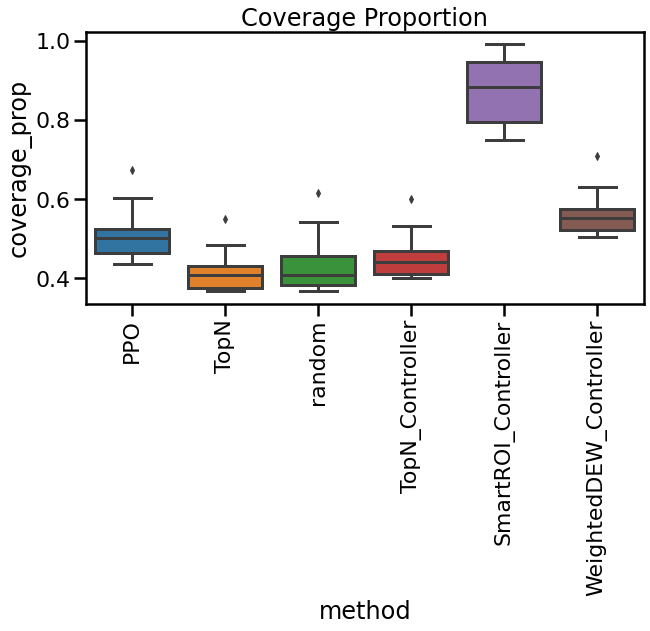

In [26]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='method', y='coverage_prop')
plt.xticks(rotation=90)
plt.title('Coverage Proportion')

Text(0.5, 1.0, 'Intensity Proportion')

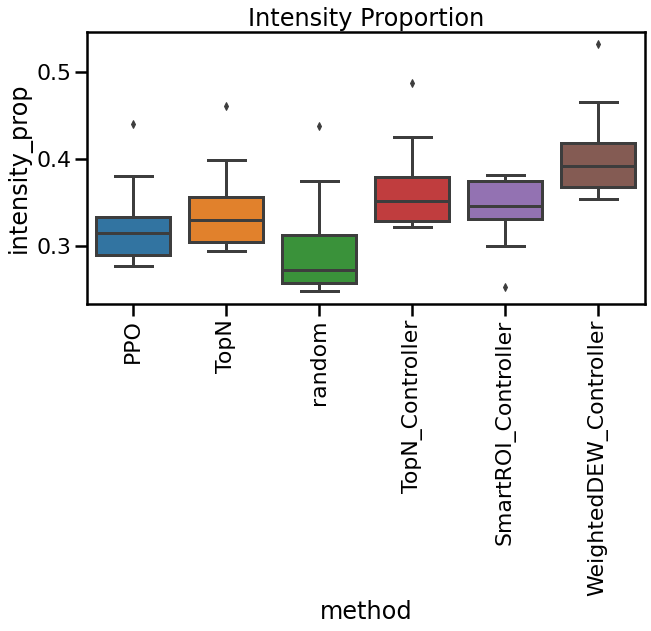

In [27]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='method', y='intensity_prop')
plt.xticks(rotation=90)
plt.title('Intensity Proportion')

Text(0.5, 1.0, 'MS1/MS2 Ratio')

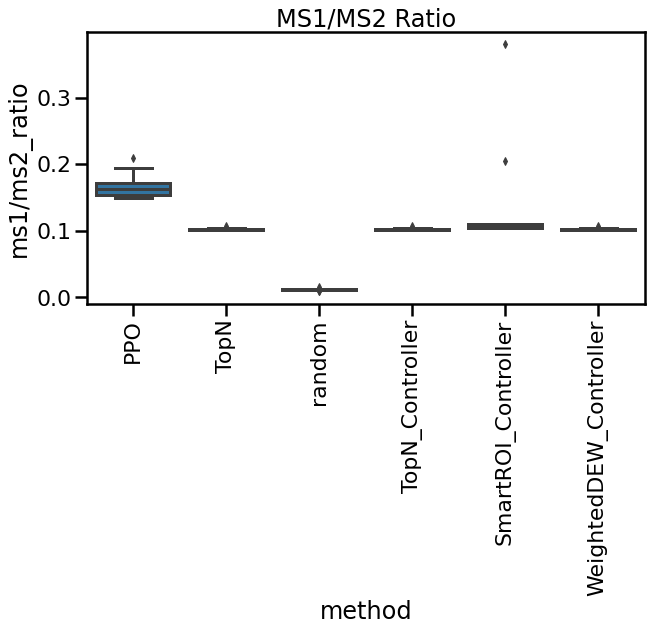

In [28]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='method', y='ms1/ms2_ratio')
plt.xticks(rotation=90)
plt.title('MS1/MS2 Ratio')

Text(0.5, 1.0, 'Efficiency')

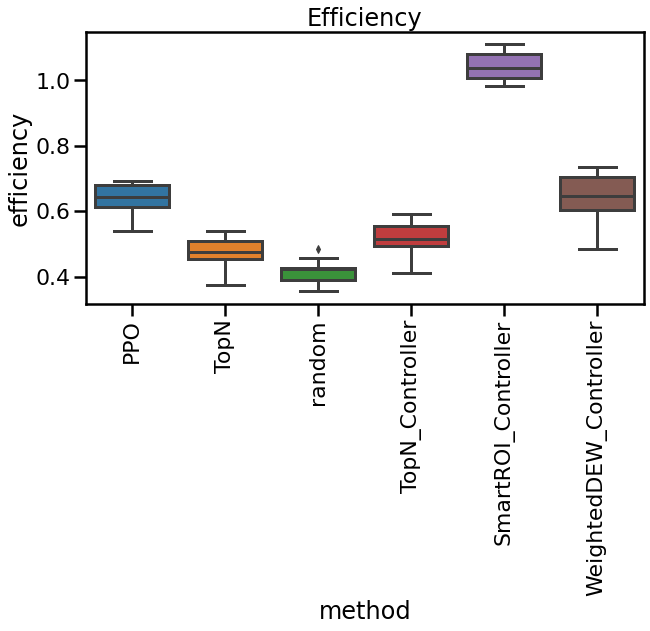

In [29]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='method', y='efficiency')
plt.xticks(rotation=90)
plt.title('Efficiency')